# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

In [2]:
# Configurações de estilo para os gráficos da apresentação
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

<a class="anchor" id="1.1 Import Libraries">

## 1.2 Data Loading
    
</a>

In [3]:
#file_path_BNP = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_BNP_teste = r"C:\Users\Catarina\Documents\GitHub\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"

# Ler o ficheiro parquet
#BNP = pd.read_csv(file_path_BNP)
BNP_teste = pd.read_csv(file_path_BNP_teste)

# Carregar o dataset pré-processado
df = pd.read_csv(file_path_BNP_teste)

<a class="anchor" id="1.1 Import Libraries">

## 2. Target Engineering
    
</a>

In [4]:
# 1. Target para Classificação (Binário)
df['TARGET'] = df['CHURN'].fillna(0).astype(int)

# 2. Targets para Sobrevivência (Event e Duration)
df['event'] = df['TARGET']
# Garantimos que a duração é no mínimo 1 dia para o Cox não crashar
df['duration'] = df['DOSSIER_DURATION_DAYS'].clip(lower=1).fillna(1)

In [5]:
features_for_survival = [
    'DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC',
    'RESSO_mean', 'NBENF_mean',
    'N_PREVIOUS_DOSSIERS', 'previous_churn_rate',
    'count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean',
    'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky',
    'sdem_age', 'active_credit_ratio', 'POLE', 'PRODALP', 'PAGAMENTO', 
    'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT', 'kp_sqe', 'NATIO',
    'AGFIN', 'PTT'
]

<a class="anchor" id="1.1 Import Libraries">

## 3. Time-Based Split
    
</a>

In [6]:
# Converter a coluna para formato de data real
df['CLOSE_DATE'] = pd.to_datetime(df['CLOSE_DATE'])

# Agora o teu código já vai funcionar:
historical_df = df[df['CLOSE_DATE'].notna()].copy()
test_df = df[df['CLOSE_DATE'].isna()].copy()

cutoff_date = historical_df['CLOSE_DATE'].max() - pd.DateOffset(months=4)

X_train = historical_df[historical_df['CLOSE_DATE'] < cutoff_date].copy()
X_val = historical_df[historical_df['CLOSE_DATE'] >= cutoff_date].copy()

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test Live: {len(test_df)}")

Train: 63118 | Validation: 13528 | Test Live: 108954


## Encoding

In [7]:
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    if col in X_train.columns:
        # 4. Calcular a frequência (Frequency Encoding)
        freq_map = X_train[col].value_counts(normalize=True)
        
        # 5. Criar a nova coluna e mapear (tal como no teu exemplo)
        X_train[f'{col}_encoded'] = X_train[col].map(freq_map)
        X_val[f'{col}_encoded'] = X_val[col].map(freq_map)
        if 'X_test' in locals() or 'X_test' in globals():
            X_test[f'{col}_encoded'] = X_test[col].map(freq_map)
            
        # 6. Preencher eventuais categorias novas no teste/val com a frequência mais baixa ou 0
        X_val[f'{col}_encoded'] = X_val[f'{col}_encoded'].fillna(0)
        if 'X_test' in locals() or 'X_test' in globals():
            X_test[f'{col}_encoded'] = X_test[f'{col}_encoded'].fillna(0)

        # 7. Opcional: Remover a coluna original para não confundir o modelo
        X_train = X_train.drop(columns=[col])
        X_val = X_val.drop(columns=[col])
        if 'X_test' in locals() or 'X_test' in globals():
            X_test = X_test.drop(columns=[col])

print(f"Encoding concluído para: {cat_cols}")

Encoding concluído para: Index(['CONTRIB', 'DOSSIER', 'DCREAT', 'DCRD_0', 'POLE', 'PRODALP',
       'PAGAMENTO', 'NATIO', 'MODCONTACTO', 'NEXT_DOSSIER_DATE', 'CHURN',
       'OBS_END_DATE', 'kp_sqe', 'sdem_SITFAM', 'sdem_HABITAT'],
      dtype='object')


In [8]:
X_train.head()

,is_san,is_sol,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,...,PRODALP_encoded,PAGAMENTO_encoded,NATIO_encoded,MODCONTACTO_encoded,NEXT_DOSSIER_DATE_encoded,CHURN_encoded,OBS_END_DATE_encoded,kp_sqe_encoded,sdem_SITFAM_encoded,sdem_HABITAT_encoded
0,1,0,2024-09-30,84,3,19,1,158.359889,0.0,8000.00,...,0.750166,0.963576,0.990827,0.599037,0.001352,0.139548,0.078852,0.027932,0.199230,0.273916
3,0,1,2024-03-31,60,21,21,0,424.699203,0.0,13467.54,...,0.750166,0.963576,0.990827,0.017776,NaN,0.860452,0.105913,0.716689,0.406081,0.358741
4,0,1,2024-03-31,60,21,21,0,184.214593,0.0,5985.57,...,0.750166,0.963576,0.990827,0.017776,NaN,0.860452,0.105913,0.716689,0.406081,0.358741
5,1,0,2024-01-31,72,34,34,0,56.017772,0.0,2500.00,...,0.750166,0.036408,0.990827,0.378577,NaN,0.860452,0.283184,0.716689,0.199230,0.358741
8,0,1,2024-03-31,84,24,24,0,274.916857,0.0,12000.00,...,0.750166,0.963576,0.990827,0.599037,NaN,0.860452,0.105913,0.716689,0.020184,0.266374


In [10]:
# Identificar colunas que são datas
#date_cols = X_train.select_dtypes(include=['datetime64']).columns

# Remover essas colunas
#X_train = X_train.drop(columns=date_cols)
#X_val = X_val.drop(columns=date_cols)
#X_test = X_test.drop(columns=date_cols)

#print(f"Colunas de data removidas: {list(date_cols)}")

# 3. Agora a variância corre sem problemas
#variances = X_train.var()
#low_variance_cols = variances[variances < 0.01].index
# ... continuar o drop das low_variance_cols

Colunas de data removidas: []


<a class="anchor" id="1.1 Import Libraries">

## 4. Feature Selection
    
</a>

### 4.1 Filter Methods

#### Variance

In [11]:
# Agora o .var() já consegue calcular tudo
variances = X_train.var()

# Identificar colunas com quase nenhuma variação (threshold 0.01)
low_variance_cols = variances[variances < 0.01].index

print(low_variance_cols)

Index(['CRD_min', 'NATIO_encoded', 'sdem_HABITAT_encoded'], dtype='object')


### Correlation Matrix

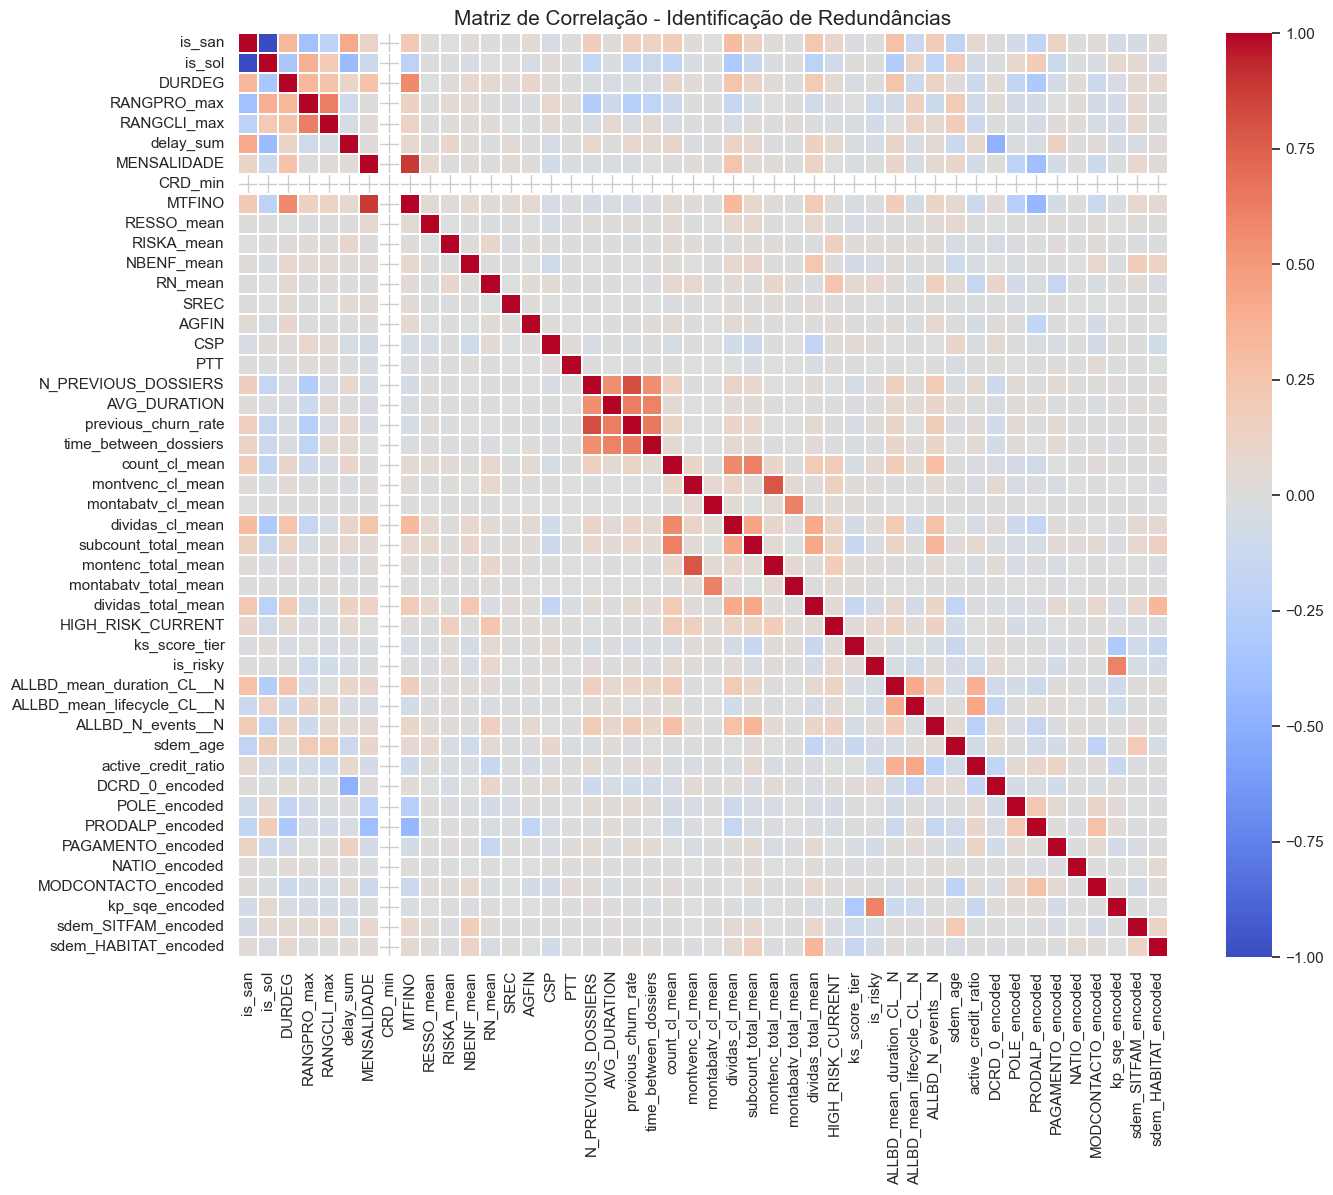

In [12]:
# 1. Calcular a matriz de correlação
corr_matrix = X_train.corr()

# 2. Visualização com Heatmap
plt.figure(figsize=(15, 12))
# Usamos um mapa de cores divergente (coolwarm) para distinguir correlações positivas e negativas
sns.heatmap(corr_matrix, 
            annot=False, # Definimos como False porque com muitas colunas os números não se leem
            cmap='coolwarm', 
            vmin=-1, vmax=1, # Escala fixa de -1 a 1
            linewidths=0.1)

plt.title("Matriz de Correlação - Identificação de Redundâncias", fontsize=15)
plt.show()

### MI

In [13]:
# 1. Computing Mutual Information (MI) para CLASSIFICAÇÃO
# Mudamos para mutual_info_classif porque o TARGET (Churn) é 0 ou 1
print("A calcular MI no dataset completo... (pode demorar)")
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# 2. Criar o DataFrame para associar nomes e scores
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 3. Exibir as top 15
print(mi_df.head(15))

# 4. Selecionar os nomes das top 15
top_mi_features = mi_df.head(15)['Feature'].tolist()

# 5. Criar o dataset reduzido
X_train_mi = X_train[top_mi_features]
X_val_mi = X_val[top_mi_features] # Não esqueças de aplicar também à validação!

A calcular MI no dataset completo... (pode demorar)
                       Feature  MI_Score
33  ALLBD_mean_lifecycle_CL__N  0.114345
32   ALLBD_mean_duration_CL__N  0.086513
9                   RESSO_mean  0.080474
24             dividas_cl_mean  0.071401
28          dividas_total_mean  0.057035
0                       is_san  0.048663
1                       is_sol  0.046405
21               count_cl_mean  0.045194
36         active_credit_ratio  0.045007
5                    delay_sum  0.041237
19         previous_churn_rate  0.034588
25         subcount_total_mean  0.033934
3                  RANGPRO_max  0.029629
37              DCRD_0_encoded  0.026479
6                  MENSALIDADE  0.020254


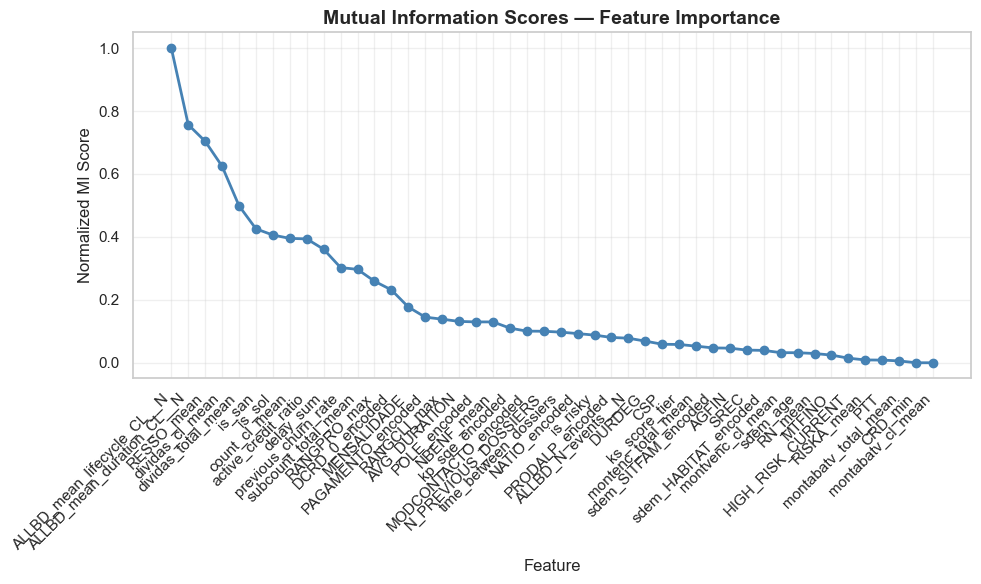

In [14]:
#sorting the dataframe by Mutual Information score in descending order
#and reseting the index
mi_df = mi_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

#normalizing the MI scores by dividing each value by the maximum MI score
#this scales the values to [0, 1] for easier comparison
mi_df['MI_Score_norm'] = mi_df['MI_Score'] / mi_df['MI_Score'].max()

#creating a figure for the Mutual Information curve
plt.figure(figsize=(10, 6))

#plotting normalized MI scores against feature names
plt.plot( mi_df['Feature'], mi_df['MI_Score_norm'], marker='o', color='steelblue', linewidth=2)

#adding a title, labelling the axes, rotating features, 
#adding a light grid and adjusting the layout
plt.title("Mutual Information Scores — Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Normalized MI Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()

#displaying the plot
plt.show()

## Wrapper Methods

In [15]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# 1. Definir o modelo "professor" 
# Usamos Random Forest porque lida bem com relações não-lineares e não precisa de scaling
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

# 2. Configurar o RFE
# n_features_to_select: quantas queremos no final (vamos pedir 15 para começar)
# step: remove 5 de cada vez para ser mais rápido
selector = RFE(estimator=rf, n_features_to_select=15, step=5, verbose=1)

In [16]:
print("A treinar o modelo de seleção (RFE)...")
selector.fit(X_train, y_train)

# 4. Extrair os resultados
selected_features = X_train.columns[selector.get_support()].tolist()
ranking = pd.DataFrame({'Feature': X_train.columns, 'Ranking': selector.ranking_}).sort_values('Ranking')

print(f"\n✅ O modelo escolheu estas 15 variáveis: \n{selected_features}")

A treinar o modelo de seleção (RFE)...
Fitting estimator with 46 features.
Fitting estimator with 41 features.
Fitting estimator with 36 features.
Fitting estimator with 31 features.
Fitting estimator with 26 features.
Fitting estimator with 21 features.
Fitting estimator with 16 features.

✅ O modelo escolheu estas 15 variáveis: 
['is_san', 'is_sol', 'RANGPRO_max', 'delay_sum', 'RESSO_mean', 'AVG_DURATION', 'previous_churn_rate', 'time_between_dossiers', 'count_cl_mean', 'dividas_cl_mean', 'dividas_total_mean', 'ALLBD_mean_duration_CL__N', 'ALLBD_mean_lifecycle_CL__N', 'active_credit_ratio', 'DCRD_0_encoded']


## Embedded methods

#### Random Forest

In [17]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63118 entries, 0 to 185599
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   is_san                      63118 non-null  int64  
 1   is_sol                      63118 non-null  int64  
 2   DURDEG                      63118 non-null  int64  
 3   RANGPRO_max                 63118 non-null  int64  
 4   RANGCLI_max                 63118 non-null  int64  
 5   delay_sum                   63118 non-null  int64  
 6   MENSALIDADE                 63118 non-null  float64
 7   CRD_min                     63118 non-null  float64
 8   MTFINO                      63118 non-null  float64
 9   RESSO_mean                  63118 non-null  float64
 10  RISKA_mean                  63118 non-null  float64
 11  NBENF_mean                  63118 non-null  float64
 12  RN_mean                     63118 non-null  float64
 13  SREC                        63118 n


📊 Relatório de Classificação (Validation Set):
              precision    recall  f1-score   support

           0       0.59      0.27      0.37      3063
           1       0.82      0.95      0.88     10465

    accuracy                           0.79     13528
   macro avg       0.70      0.61      0.62     13528
weighted avg       0.76      0.79      0.76     13528

🏆 ROC-AUC Score: 0.7485


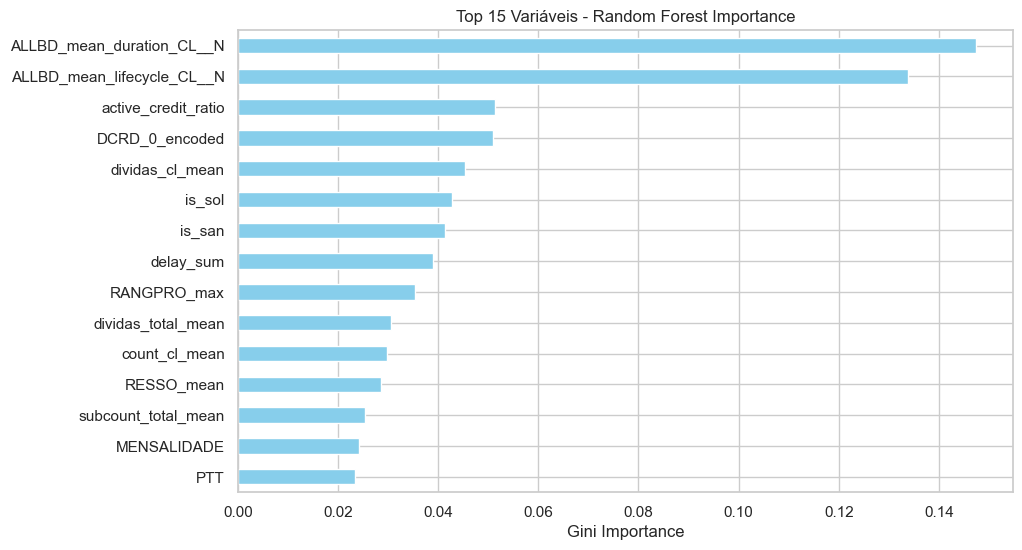

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1
)

# 2. Treinar o modelo
rf_model.fit(X_train, y_train)

# 3. Fazer as Previsões de Validação (O "Certificado de Qualidade" do João)
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

# 4. Mostrar as Métricas (Benchmarking antecipado)
print("\n📊 Relatório de Classificação (Validation Set):")
print(classification_report(y_val, y_val_pred))
print(f"🏆 ROC-AUC Score: {roc_auc_score(y_val, y_val_prob):.4f}")

# 5. Extrair e Visualizar a Importância das Variáveis (A Seleção propriamente dita)
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variáveis - Random Forest Importance")
plt.xlabel("Gini Importance")
plt.show()

# Guardar a lista das top 15 para o consenso final
rf_selected_features = rf_importance.head(15).index.tolist()

#### XGBOOST

In [17]:
#pip install xgboost

In [18]:
#cols_to_drop = ['MENSALIDADE', 'N_PREVIOUS_DOSSIERS', 'CRD_min']
#X_train_xgb = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
#X_val_xgb = X_val.drop(columns=[c for c in cols_to_drop if c in X_val.columns])

Negative class count: 8808
Positive class count: 54310
scale_pos_weight: 0.16218007733382434
A treinar XGBoost com scale_pos_weight: 0.16...
              precision    recall  f1-score   support

           0       0.36      0.78      0.49      3063
           1       0.90      0.59      0.72     10465

    accuracy                           0.64     13528
   macro avg       0.63      0.68      0.60     13528
weighted avg       0.78      0.64      0.66     13528

 Validation ROC-AUC:: 0.7647


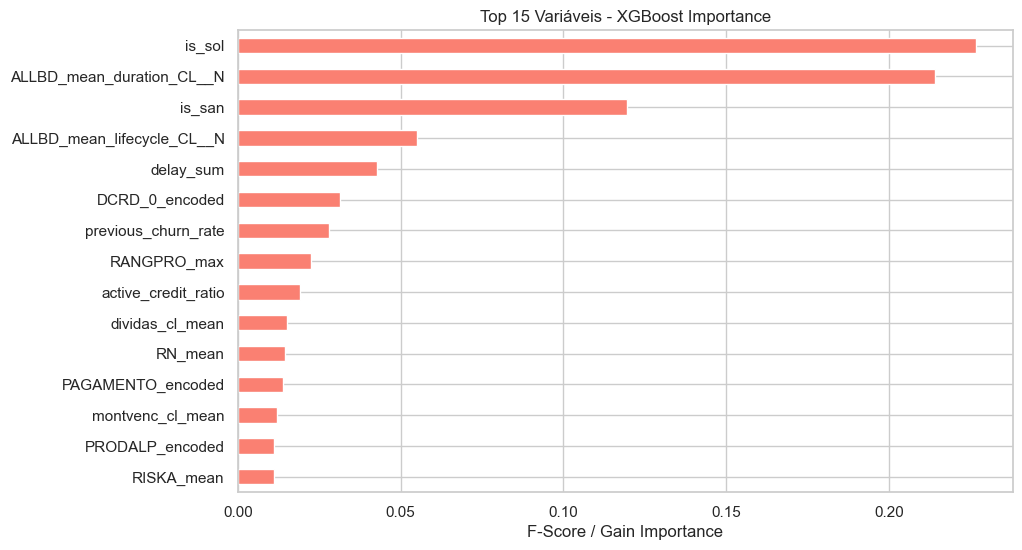

In [30]:
# 2. Calcular o weights
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Negative class count:", neg)
print("Positive class count:", pos)
print("scale_pos_weight:", scale_pos_weight)

# 3. Configurar o Modelo 
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,                # Árvores menos profundas para evitar overfitting
    learning_rate=0.05,         # Passo mais lento para maior precisão
    subsample=0.8,              # Usa 80% dos dados em cada árvore
    colsample_bytree=0.8,       # Usa 80% das colunas em cada árvore
    scale_pos_weight=scale_pos_weight, 
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 4. Treinar o modelo
print(f"A treinar XGBoost com scale_pos_weight: {scale_pos_weight:.2f}...")
xgb_model.fit(X_train, y_train)

# 5. Previsões e Avaliação (O "Selo de Garantia")
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred_xgb))
print(f" Validation ROC-AUC:: {roc_auc_score(y_val, y_val_prob_xgb):.4f}")


# 6. Visualização das Top 15 Variáveis
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title("Top 15 Variáveis - XGBoost Importance")
plt.xlabel("F-Score / Gain Importance")
plt.show()

xgb_selected_features = xgb_importance.head(15).index.tolist()

In [20]:
# --- RECONSTRUÇÃO SEGURA DOS TARGETS DE SOBREVIVÊNCIA ---

df['event'] = df['TARGET']
if 'DOSSIER_DURATION_DAYS' in df.columns:
    df['duration'] = df['DOSSIER_DURATION_DAYS'].clip(lower=1)
else:
    df['duration'] = 1 # Fallback de segurança

In [23]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63118 entries, 0 to 185599
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   is_san                      63118 non-null  int64  
 1   is_sol                      63118 non-null  int64  
 2   DCRD_0                      63118 non-null  float64
 3   DURDEG                      63118 non-null  int64  
 4   RANGPRO_max                 63118 non-null  int64  
 5   RANGCLI_max                 63118 non-null  int64  
 6   delay_sum                   63118 non-null  int64  
 7   MENSALIDADE                 63118 non-null  float64
 8   CRD_min                     63118 non-null  float64
 9   MTFINO                      63118 non-null  float64
 10  RESSO_mean                  63118 non-null  float64
 11  RISKA_mean                  63118 non-null  float64
 12  NBENF_mean                  63118 non-null  float64
 13  RN_mean                     63118 n

### COX

In [28]:
# 1. Começamos com o X_train (que já tem as colunas _encoded e os drops feitos)
train_survival = X_train.copy()

# 2. Vamos buscar apenas a 'duration' e o 'event' ao df original usando o índice
train_survival['duration'] = df.loc[X_train.index, 'duration']
train_survival['event'] = df.loc[X_train.index, 'event']

# 3. Limpar NaNs que possam ter vindo nestas duas colunas
train_survival = train_survival.dropna()

# scaling
scaler = StandardScaler()
features_to_scale = X_train.columns.tolist()
train_survival[features_to_scale] = scaler.fit_transform(train_survival[features_to_scale])

# Penalized cox model
cph_l1 = CoxPHFitter(penalizer=0.1, l1_ratio=1)

cph_l1.fit(train_survival, duration_col='duration', event_col='event')

# checking the coefficients
cox_l1_results = cph_l1.summary[['coef', 'exp(coef)', 'p']]

# feature importance (Ordenado pelo valor absoluto do coeficiente)
cox_l1_sorted = cox_l1_results.reindex(cox_l1_results['coef'].abs().sort_values(ascending=False).index)

print("\nFeatures ordered by importance (|coef|):")
print(cox_l1_sorted.head(15)) # Mostramos as top 15

# checking to see if L1 removed any feature
selected_features = cox_l1_results[cox_l1_results['coef'] != 0]

if len(selected_features) == len(cox_l1_results):
    print("\nLasso did not remove any features (all coefficients ≠ 0).")
else:
    removed = set(cox_l1_results.index) - set(selected_features.index)
    print(f"\nFeatures removed by L1 Cox ({len(removed)} colunas):")
    print(removed)

c:\Users\Catarina\anaconda3\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1530: LinAlgWarning: Ill-conditioned matrix (rcond=3.40214e-18): result may not be accurate.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.